In [2]:
import requests

url = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
output_file = "C:/Users/ak20adb/OneDrive - University of Hertfordshire/Pictures/portfolio/dataset_diabetes.zip"

# Simulate API download
response = requests.get(url)
with open(output_file, 'wb') as f:
    f.write(response.content)
print("✅ Data downloaded")


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/ak20adb/OneDrive - University of Hertfordshire/Pictures/portfolio/dataset_diabetes.zip'

In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt

df = pd.read_csv("D:/portfolio/diabetic_data.csv")



print (df)

        encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)      ?   
1             149190     55629189        Caucasian  Female  [10-20)      ?   
2              64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3             500364     82442376        Caucasian    Male  [30-40)      ?   
4              16680     42519267        Caucasian    Male  [40-50)      ?   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)      ?   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)      ?   
101763     443854148     41088789        Caucasian    Male  [70-80)      ?   
101764     443857166     31693671        Caucasian  Female  [80-90)      ?   
101765     443867222    175429310        Caucasian    Male  [70-80)      ?   

        admission_type_id  discharge_disposition_id  admission_

In [37]:
df.replace('?', np.nan, inplace=True)
df.replace(r'\[', '', regex=True, inplace=True)
df.replace(r'\)', '', regex=True, inplace=True)
df['age_avg'] = df['age'].str.extract(r'(\d+)-(\d+)').astype(float).mean(axis=1)
df['gender_values'] = df['gender']

df['gender_values'] = df['gender_values'].replace('Female', 1)
df['gender_values'] = df['gender_values'].replace('Male', 0)

# Step 1: Create a copy of the 'change' column
df['change_values'] = df['change']

# Step 2: Replace values in the new 'change_values' column
df['change_values'] = df['change_values'].replace('No', 0)
df['change_values'] = df['change_values'].replace('Ch', 1)


#df['readmitted'] = df['readmitted'].map(readmitted_mapping)

print(df['gender_values'], df['readmitted'])

0         1
1         1
2         1
3         0
4         0
         ..
101761    0
101762    1
101763    0
101764    1
101765    0
Name: gender_values, Length: 101766, dtype: object 0          NO
1         >30
2          NO
3          NO
4          NO
         ... 
101761    >30
101762     NO
101763     NO
101764     NO
101765     NO
Name: readmitted, Length: 101766, dtype: object


C:\Users\altin\AppData\Local\Temp\ipykernel_13276\846459673.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['change_values'] = df['change_values'].replace('Ch', 1)


In [6]:
from sqlalchemy import create_engine

print(df['change_values'])

columns_to_change = [
    'gender_values', 'readmitted'
]

df2 = df[columns_to_change]

username = "root"
password = "1234"
host = "localhost"   # or your MySQL server IP
port = "3306"
database = "diabetes_schema"

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Save DataFrame to MySQL (replace 'people' with your table name)
df2.to_sql("peaple2", engine, if_exists="replace", index=False)

# df.to_csv('C:/Users/ak20adb/OneDrive - University of Hertfordshire/Pictures/portfolio/test1.csv')


0         0
1         1
2         0
3         1
4         1
         ..
101761    1
101762    0
101763    1
101764    1
101765    0
Name: change_values, Length: 101766, dtype: int64


101766

In [26]:
username = "root"
password = "1234"
host = "localhost"   # or your MySQL server IP
port = "3306"
database = "diabetes_schema"

# Load CSV
df3 = pd.read_csv("D:/portfolio/ICD9_mapping.csv")

# Create SQLAlchemy engine
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")


# Split tables
patients = df[[
    'patient_nbr', 'race', 'gender', 'age', 'weight', 'age_avg', 'gender_values'
]].drop_duplicates(subset='patient_nbr')

encounters = df[[
    'encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'time_in_hospital', 'payer_code',
    'medical_specialty', 'readmitted'
]].drop_duplicates(subset='encounter_id')

labs_procedures = df[[
    'encounter_id', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses'
]]

diagnoses = df[[
    'encounter_id', 'diag_1', 'diag_2', 'diag_3'
]]

diagnoses_mapping = df3[[
    'ICD9_min', 'ICD9_max', 'diagnosis'
]]

med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'change', 'change_values', 'diabetesMed',
    'A1Cresult', 'max_glu_serum'
]
medications = df[['encounter_id'] + med_cols]

linking_table = df[['encounter_id', 'patient_nbr']].drop_duplicates()

# Save to MySQL
patients.to_sql("patients", engine, if_exists="replace", index=False)
encounters.to_sql("encounters", engine, if_exists="replace", index=False)
labs_procedures.to_sql("labs_procedures", engine, if_exists="replace", index=False)
diagnoses.to_sql("diagnoses", engine, if_exists="replace", index=False)
medications.to_sql("medications", engine, if_exists="replace", index=False)
linking_table.to_sql("linking_table", engine, if_exists="replace", index=False)
diagnoses_mapping.to_sql("diagnoses_mapping", engine, if_exists="replace", index=False)


18

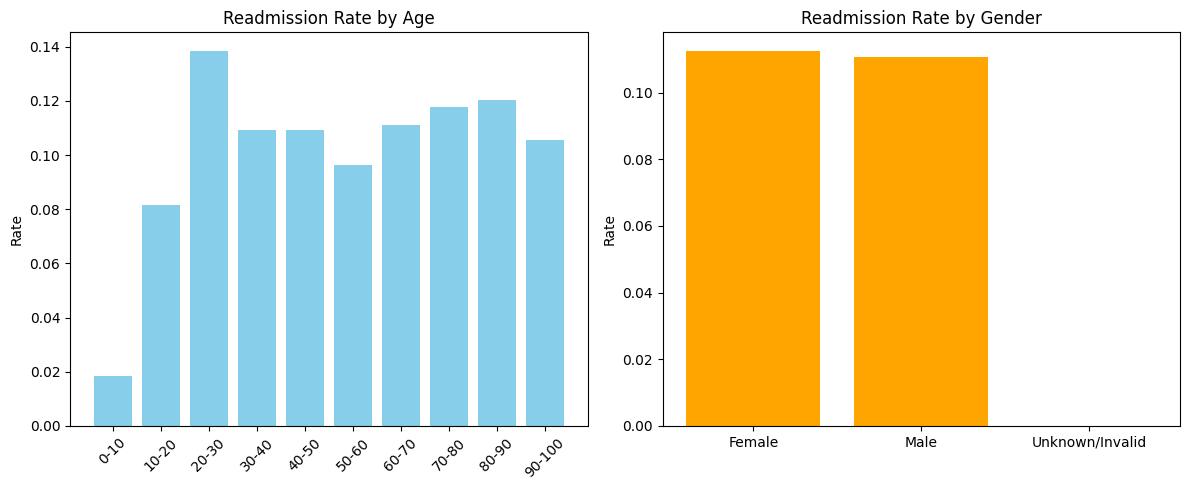

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# MySQL credentials
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

# Create SQLAlchemy engine (only once)
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# --- Query 1: Readmission rate by AGE ---
query_age = """
SELECT 
    p.age,
    COUNT(*) AS total,
    SUM(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) AS readmitted_30
FROM 
    encounters e
LEFT JOIN
    patients p ON e.patient_nbr = p.patient_nbr
GROUP BY 
    p.age
ORDER BY 
    p.age;
"""

# --- Query 2: Readmission rate by GENDER ---
query_gender = """
SELECT 
    p.gender,
    COUNT(*) AS total,
    SUM(CASE WHEN e.readmitted = '<30' THEN 1 ELSE 0 END) AS readmitted_30
FROM 
    encounters e
LEFT JOIN
    patients p ON e.patient_nbr = p.patient_nbr
GROUP BY 
    p.gender
ORDER BY 
    p.gender;
"""

# Load into DataFrames
df_age = pd.read_sql(query_age, engine)
df_gender = pd.read_sql(query_gender, engine)

# Compute readmission rates
df_age["readmission_rate"] = df_age["readmitted_30"] / df_age["total"]
df_gender["readmission_rate"] = df_gender["readmitted_30"] / df_gender["total"]

# Save summary tables back into SQL (for BI)
df_age.to_sql("readmission_by_age", engine, if_exists="replace", index=False)
df_gender.to_sql("readmission_by_gender", engine, if_exists="replace", index=False)

# --- Plotting ---
plt.figure(figsize=(12, 5))

# Plot 1: Readmission rate by age
plt.subplot(1, 2, 1)
plt.bar(df_age["age"], df_age["readmission_rate"], color="skyblue")
plt.xticks(rotation=45)
plt.title("Readmission Rate by Age")
plt.ylabel("Rate")

# Plot 2: Readmission rate by gender
plt.subplot(1, 2, 2)
plt.bar(df_gender["gender"], df_gender["readmission_rate"], color="orange")
plt.title("Readmission Rate by Gender")
plt.ylabel("Rate")

plt.tight_layout()
plt.show()


  readmitted  avg_lab_procedures  avg_medications  avg_inpatient_visits  \
0        <30             44.2260          16.9031                 1.224   
1        >30             43.8366          16.2828                 0.839   
2         NO             42.3816          15.6704                 0.382   

   total_encounters  
0             11357  
1             35545  
2             54864  


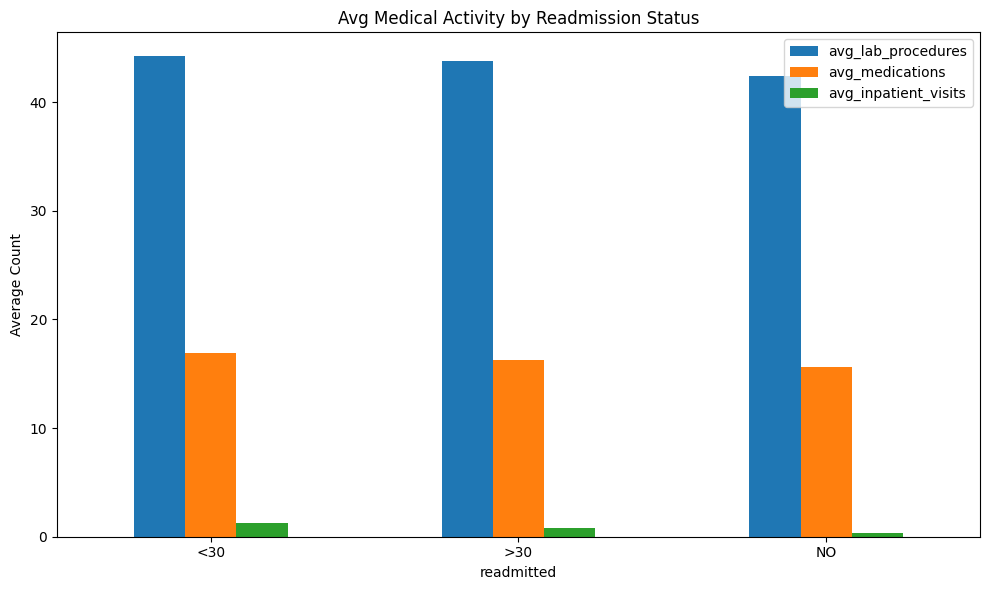

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# MySQL credentials
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

# Create SQLAlchemy engine (once is enough)
engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Query: medical activity vs readmission
query = """
SELECT 
    e.readmitted,
    AVG(l.num_lab_procedures) AS avg_lab_procedures,
    AVG(l.num_medications) AS avg_medications,
    AVG(l.number_inpatient) AS avg_inpatient_visits,
    COUNT(*) AS total_encounters
FROM 
    encounters e
JOIN
    labs_procedures l ON e.encounter_id = l.encounter_id
GROUP BY 
    e.readmitted
ORDER BY
    FIELD(e.readmitted, '<30', '>30', 'NO');
"""

# Load into DataFrame
df_correlation = pd.read_sql(query, engine)

# (Optional) save to SQL for Power BI
df_correlation.to_sql("readmission_vs_medical_activity", engine, if_exists="replace", index=False)

print(df_correlation)



In [19]:
import pandas as pd
from sqlalchemy import create_engine

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# 1) Discharge disposition vs readmission
query_discharge = """
SELECT 
    discharge_disposition_id,
    COUNT(*) AS total_encounters,
    SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) AS readmitted_30,
    ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) / COUNT(*), 3) AS readmission_rate
FROM 
    encounters
GROUP BY 
    discharge_disposition_id
ORDER BY 
    readmission_rate DESC, total_encounters DESC;
"""

df_discharge = pd.read_sql(query_discharge, engine)
df_discharge.to_sql("readmission_by_discharge", engine, if_exists="replace", index=False)

# 2) Admission type vs readmission
query_admission = """
SELECT 
    admission_type_id,
    COUNT(*) AS total_encounters,
    SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) AS readmitted_30,
    ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) / COUNT(*), 3) AS readmission_rate
FROM 
    encounters
GROUP BY 
    admission_type_id
ORDER BY 
    readmission_rate DESC, total_encounters DESC;
"""

df_admission = pd.read_sql(query_admission, engine)
df_admission.to_sql("readmission_by_admission_type", engine, if_exists="replace", index=False)

print("✅ created readmission_by_discharge and readmission_by_admission_type")


✅ created readmission_by_discharge and readmission_by_admission_type


In [20]:
import pandas as pd
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Query: overall readmission rate
query_overall = """
SELECT 
    COUNT(*) AS total_encounters,
    SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) AS readmitted_30,
    ROUND(SUM(CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END) / COUNT(*), 3) AS readmission_rate
FROM 
    encounters;
"""

# Load to DataFrame
df_overall = pd.read_sql(query_overall, engine)

# Save to MySQL for Power BI
df_overall.to_sql("readmission_overall_rate", engine, if_exists="replace", index=False)

print(df_overall)


   total_encounters  readmitted_30  readmission_rate
0            101766        11357.0             0.112


In [40]:
# Convert diag columns to numeric
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert ICD9 mapping columns to numeric
for col2 in ['ICD9_min', 'ICD9_max']:
    df3[col2] = pd.to_numeric(df3[col2], errors='coerce')

# Create a new empty column for results
df['new'] = None
df['new1'] = None
df['new2'] = None

# Loop through each row in df
for i in range(len(df)):
    code = df.loc[i, 'diag_1']
    code1 = df.loc[i, 'diag_2']
    code2 = df.loc[i, 'diag_3']
    
    # Skip if code is missing
    if pd.isna(code):
        continue
    if pd.isna(code1):
        continue
    if pd.isna(code2):
        continue
    
    # Loop through ICD9 ranges
    for j in range(len(df3)):
        icd_min = df3.loc[j, 'ICD9_min']
        icd_max = df3.loc[j, 'ICD9_max']
        
        if icd_min <= code <= icd_max:
            df.loc[i, 'new'] = df3.loc[j, 'diagnosis']
        
        if icd_min <= code1 <= icd_max:
            df.loc[i, 'new1'] = df3.loc[j, 'diagnosis']

        if icd_min <= code2 <= icd_max:
            df.loc[i, 'new2'] = df3.loc[j, 'diagnosis']


print(df[['diag_1', 'new']].head(5))
print(df[['diag_2', 'new1']].head(5))
print(df[['diag_3', 'new2']].head(5))



   diag_1                                                new
0  250.83                                               None
1  276.00  Endocrine, Nutritional and Metabolic Diseases ...
2  648.00                                               None
3    8.00                  Infection and Parasitic Diseases 
4  197.00                                         Neoplasms 
   diag_2                                               new1
0     NaN                                               None
1  250.01  Endocrine, Nutritional and Metabolic Diseases ...
2  250.00                                               None
3  250.43  Endocrine, Nutritional and Metabolic Diseases ...
4  157.00                                         Neoplasms 
   diag_3                                               new2
0     NaN                                               None
1   255.0  Endocrine, Nutritional and Metabolic Diseases ...
2     NaN                                               None
3   403.0               

In [42]:
df_test = pd.DataFrame()

# Convert diag columns to numeric
for col in ['diag_1', 'diag_2', 'diag_3']:
    df_test[col] = pd.to_numeric(df[col], errors='coerce')

print (df_test)

        diag_1  diag_2  diag_3
0       250.83     NaN     NaN
1       276.00  250.01   255.0
2       648.00  250.00     NaN
3         8.00  250.43   403.0
4       197.00  157.00   250.0
...        ...     ...     ...
101761  250.13  291.00   458.0
101762  560.00  276.00   787.0
101763   38.00  590.00   296.0
101764  996.00  285.00   998.0
101765  530.00  530.00   787.0

[101766 rows x 3 columns]


In [44]:
# Convert diag columns to numeric
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert ICD9 mapping columns to numeric
for col2 in ['ICD9_min', 'ICD9_max']:
    df3[col2] = pd.to_numeric(df3[col2], errors='coerce')

# Create a new empty column for results
df['new'] = None
df['new1'] = None
df['new2'] = None

# Loop through each row in df
for i in range(len(df)):
    code = df.loc[i, 'diag_1']
    code1 = df.loc[i, 'diag_2']
    code2 = df.loc[i, 'diag_3']
    # Skip if code is missing
    if pd.isna(code):
        continue
    
    # Loop through ICD9 ranges
    for j in range(len(df3)):
        icd_min = df3.loc[j, 'ICD9_min']
        icd_max = df3.loc[j, 'ICD9_max']
        
        if icd_min <= code <= icd_max:
            df.loc[i, 'new'] = df3.loc[j, 'diagnosis']
    
    if pd.isna(code1):
        continue


        # Loop through ICD9 ranges
    for j in range(len(df3)):
        icd_min = df3.loc[j, 'ICD9_min']
        icd_max = df3.loc[j, 'ICD9_max']
        
        if icd_min <= code1 <= icd_max:
            df.loc[i, 'new1'] = df3.loc[j, 'diagnosis']

    if pd.isna(code2):
        continue        

        # Loop through ICD9 ranges
    for j in range(len(df3)):
        icd_min = df3.loc[j, 'ICD9_min']
        icd_max = df3.loc[j, 'ICD9_max']
        
        if icd_min <= code2 <= icd_max:
            df.loc[i, 'new2'] = df3.loc[j, 'diagnosis']
        


print(df[['diag_1', 'new']].head(5))

print(('---------------'), df[['diag_2', 'new1']].head(5))
print(('---------------'), df[['diag_3', 'new2']].head(5))


   diag_1                                                new
0  250.83  Endocrine, Nutritional and Metabolic Diseases ...
1  276.00  Endocrine, Nutritional and Metabolic Diseases ...
2  648.00  Complications of Pregnancy, Childbirth and the...
3    8.00                  Infection and Parasitic Diseases 
4  197.00                                         Neoplasms 
---------------    diag_2                                               new1
0     NaN                                               None
1  250.01  Endocrine, Nutritional and Metabolic Diseases ...
2  250.00  Endocrine, Nutritional and Metabolic Diseases ...
3  250.43  Endocrine, Nutritional and Metabolic Diseases ...
4  157.00                                         Neoplasms 
---------------    diag_3                                               new2
0     NaN                                               None
1   255.0  Endocrine, Nutritional and Metabolic Diseases ...
2     NaN                                            

In [46]:
pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 3.0 MB/s eta 0:00:24
    --------------------------------------- 1.0/72.0 MB 2.8 MB/s eta 0:00:25
   - -------------------------------------- 1.8/72.0 MB 2.9 MB/s eta 0:00:24
   - -------------------------------------- 2.4/72.0 MB 3.0 MB/s eta 0:00:24
   - -------------------------------------- 3.1/72.0 MB 3.0 MB/s eta 0:00:23
   -- ------------------------------------- 3.7/72.0 MB 3.0 MB/s eta 0:00:23
   -- ------------------------------------- 4.5/72.0 MB 3.0 MB/s eta 0:00:23
   -- ------------------------------------- 5.0/72.0 MB 3.0 MB/s eta 0:00:23
   --- ------------------------------------ 5.8/72.0 MB 3.0 MB/s eta 0:00:22
   --- ------------------------------------ 6.3/72.0 MB 3.0 MB/s eta 0:00:22
   --- ------------------------------------ 6.8/72.0 MB 3.0 MB/s eta 0:00:22
   ---- ----------------------------------- 7.6/72.0 MB 3.0 MB/s eta 0:00:22
   ---


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [87]:
import pandas as pd
from sqlalchemy import create_engine

# ------------------------------------
# 1. MySQL Connection
# ------------------------------------
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# ------------------------------------
# 2. Load Data from MySQL
# ------------------------------------
df = pd.read_sql("""
    SELECT * FROM encounters e
    LEFT JOIN patients p ON e.patient_nbr = p.patient_nbr
    LEFT JOIN labs_procedures l ON e.encounter_id = l.encounter_id
    LEFT JOIN medications m ON e.encounter_id = m.encounter_id
""", engine)

print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ------------------------------------
# 3. Drug mapping
# ------------------------------------
drug_mapping = {
    "No": 0,
    "Down": 1,
    "Up": 1,
    "Steady": 1
}

drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]

# Apply mapping safely to all drug columns
for col in drug_cols:
    if col in df.columns:
        df[col] = df[col].map(drug_mapping).fillna(0)

# ------------------------------------
# 4. Create total drug count column
# ------------------------------------
df["drug_num"] = df[drug_cols].sum(axis=1)

# ------------------------------------
# 5. Encode readmission and gender
# ------------------------------------
df["readmitted_30"] = df["readmitted"].map({
    "<30": 1,
    ">30": 1,
    "NO": 0
}).fillna(0)

df["gender_values"] = pd.to_numeric(df["gender_values"], errors="coerce").fillna(0)

# ------------------------------------
# 6. Preview cleaned data
# ------------------------------------
print(df[["readmitted", "readmitted_30", "gender", "gender_values", "drug_num"]].head())


✅ Data loaded: 101766 rows, 53 columns
  readmitted  readmitted_30  gender  gender_values  drug_num
0         NO              0  Female            1.0         0
1        >30              1  Female            1.0         1
2         NO              0  Female            1.0         1
3         NO              0    Male            0.0         1
4         NO              0    Male            0.0         2


Cross-validation accuracy scores: [0.6251 0.6205 0.618  0.6241 0.626 ]
Mean CV accuracy: 0.6228
Std deviation: 0.003

Accuracy: 0.6226711736498703

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.73      0.68     13768
           1       0.61      0.50      0.55     11674

    accuracy                           0.62     25442
   macro avg       0.62      0.61      0.61     25442
weighted avg       0.62      0.62      0.62     25442


Confusion Matrix:
 [[10037  3731]
 [ 5869  5805]]


<Figure size 1000x800 with 0 Axes>

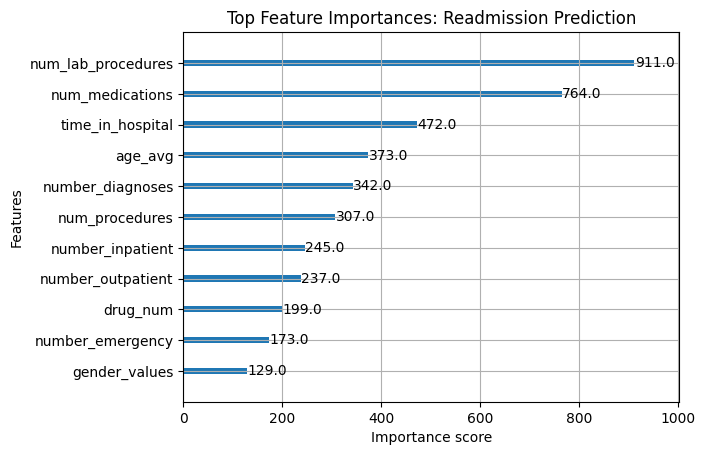

ValueError: Length mismatch: Expected axis has 4 elements, new values have 2 elements

In [91]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# ------------------------------------
# 1. DEFINE FEATURES
# ------------------------------------
numeric_features = [
    "age_avg",
    "gender_values",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses",
    "drug_num"
]

feature_set = numeric_features

X = df[feature_set]
y = df["readmitted_30"]

# Ensure no object types remain
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
y = y.fillna(0)

# ------------------------------------
# 2. TRAIN/TEST SPLIT
# ------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ------------------------------------
# 3. DEFINE XGBOOST MODEL
# ------------------------------------
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    enable_categorical=False,
    random_state=42
)

# ------------------------------------
# 4. CROSS VALIDATION (5-FOLD)
# ------------------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print("Cross-validation accuracy scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", np.mean(cv_scores).round(4))
print("Std deviation:", np.std(cv_scores).round(4))

# ------------------------------------
# 5. TRAIN MODEL ON TRAINING SET
# ------------------------------------
model.fit(X_train, y_train)

# ------------------------------------
# 6. EVALUATE ON TEST SET
# ------------------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ------------------------------------
# 7. FEATURE IMPORTANCE
# ------------------------------------
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=20)
plt.title("Top Feature Importances: Readmission Prediction")
plt.show()

# ------------------------------------
# 8. EXPORT RESULTS TO MYSQL
# ------------------------------------
df_ml = df.copy()
df_ml["ml_prediction"] = model.predict(X)

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

df_ml_export = df_ml[["encounter_id", "ml_prediction"]].copy()
df_ml_export.columns = ["encounter_id_ref", "ml_prediction"]

df_ml_export.to_sql(
    name="ml_readmission_predictions",
    con=engine,
    if_exists="replace",
    index=False
)

print("\n✅ Exported using renamed encounter_id_ref column")


print("\n✅ ML predictions exported to MySQL: ml_readmission_predictions")



Cross-validation accuracy scores: [0.6245 0.6234 0.6177 0.6218 0.6254]
Mean CV accuracy: 0.6226
Std deviation: 0.0027

Accuracy: 0.6236144957157456

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.73      0.68     13768
           1       0.61      0.50      0.55     11674

    accuracy                           0.62     25442
   macro avg       0.62      0.61      0.61     25442
weighted avg       0.62      0.62      0.62     25442


Confusion Matrix:
 [[10069  3699]
 [ 5877  5797]]


<Figure size 1200x800 with 0 Axes>

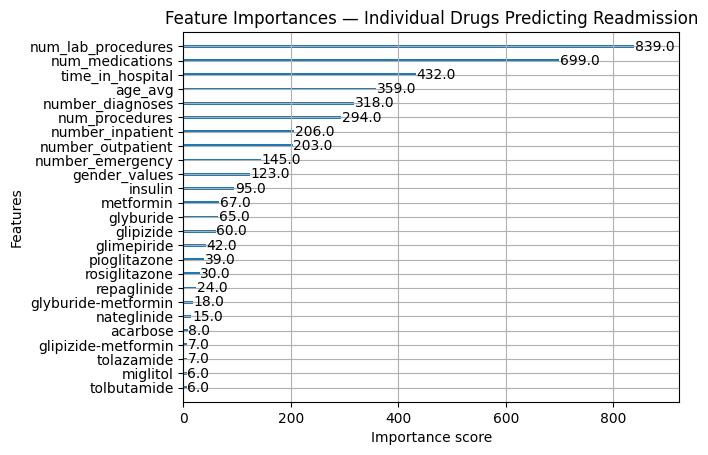


✅ ML predictions exported to MySQL: ml_drug_readmission_predictions


In [92]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# ------------------------------------
# 1. Define Features
# ------------------------------------
drug_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone'
]

# Combine demographic + drug features (NO drug_num)
numeric_features = [
    "age_avg",
    "gender_values",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses"
]

feature_set = numeric_features + drug_cols

# Prepare data
X = df[feature_set].apply(pd.to_numeric, errors="coerce").fillna(0)
y = df["readmitted_30"].fillna(0)

# ------------------------------------
# 2. Split Train/Test
# ------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ------------------------------------
# 3. Define Model
# ------------------------------------
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    enable_categorical=False,
    random_state=42
)

# ------------------------------------
# 4. Cross-Validation (5-Fold)
# ------------------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")

print("\nCross-validation accuracy scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", np.mean(cv_scores).round(4))
print("Std deviation:", np.std(cv_scores).round(4))

# ------------------------------------
# 5. Train Model on Train Set
# ------------------------------------
model.fit(X_train, y_train)

# ------------------------------------
# 6. Evaluate on Test Set
# ------------------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ------------------------------------
# 7. Feature Importance — focus on drug features
# ------------------------------------
plt.figure(figsize=(12, 8))
xgb.plot_importance(model, max_num_features=25)
plt.title("Feature Importances — Individual Drugs Predicting Readmission")
plt.show()

# ------------------------------------
# 8. Export Predictions to MySQL
# ------------------------------------
df_ml = df.copy()
df_ml["ml_prediction_drugs"] = model.predict(X)

username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Clean duplicate columns before export
df_ml = df_ml.loc[:, ~df_ml.columns.duplicated()]

df_ml[["encounter_id", "ml_prediction_drugs"]].to_sql(
    "ml_drug_readmission_predictions",
    engine,
    if_exists="replace",
    index=False
)

print("\n✅ ML predictions exported to MySQL: ml_drug_readmission_predictions")


In [96]:
# ------------------------------------
# 7. EVALUATION + PROBABILITIES
# ------------------------------------

# Predictions (0/1)
y_pred = model.predict(X_test)

# Probabilities (between 0 and 1)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of being readmitted

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Add probabilities and predictions to full dataset for export
df_ml = df.copy()
df_ml["ml_prediction"] = model.predict(X)
df_ml["prediction_probability"] = model.predict_proba(X)[:, 1]

# ------------------------------------
# 8. EXPORT TO MYSQL
# ------------------------------------
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "diabetes_schema"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Remove duplicate columns by name
df_ml = df_ml.loc[:, ~df_ml.columns.duplicated()]

# Check which columns remain
print("Columns going to MySQL:", df_ml.columns.tolist())

# Export clean table
df_ml[["encounter_id", "patient_nbr", "ml_prediction", "prediction_probability", "readmitted", "gender"]] \
    .to_sql("ml_readmission_predictions", engine, if_exists="replace", index=False)

print("✅ Exported ML predictions + probabilities to MySQL")




Accuracy: 0.6236144957157456

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.73      0.68     13768
           1       0.61      0.50      0.55     11674

    accuracy                           0.62     25442
   macro avg       0.62      0.61      0.61     25442
weighted avg       0.62      0.62      0.62     25442


Confusion Matrix:
 [[10069  3699]
 [ 5877  5797]]
Columns going to MySQL: ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'readmitted', 'race', 'gender', 'age', 'weight', 'age_avg', 'gender_values', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 